In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df=pd.read_csv(r'C:\Users\Pawan\OneDrive\Desktop\code\files\credit_risk_dataset.csv')

In [17]:
df.head(10)

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level,Housing_Status,Default
0,59,52154.0,11276,823,15,Bachelors,Own,0
1,49,116646.0,43663,315,5,PhD,Own,0
2,35,61157.0,18994,428,8,Masters,Own,1
3,63,52154.0,28499,408,26,Bachelors,Rent,0
4,28,148876.0,28040,832,3,Masters,Own,1
5,41,87506.0,48320,568,26,PhD,Own,0
6,59,107487.0,21959,461,27,Masters,Own,0
7,39,49486.0,11099,559,1,PhD,Own,1
8,43,24018.0,47267,401,28,High School,Own,0
9,31,64028.0,24576,805,3,Masters,Own,1


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1000 non-null   int64  
 1   Income            985 non-null    float64
 2   Loan_Amount       1000 non-null   int64  
 3   Credit_Score      1000 non-null   int64  
 4   Employment_Years  1000 non-null   int64  
 5   Education_Level   1000 non-null   str    
 6   Housing_Status    1000 non-null   str    
 7   Default           1000 non-null   int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 62.6 KB


In [19]:
df.describe()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Default
count,1000.000000,985.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,42.515000,82254.047716,27729.324000,581.05000,15.164000,0.138000
std,12.611059,36842.390571,12774.836247,158.59334,8.593075,0.345073
min,21.000000,20922.000000,5097.000000,300.00000,0.000000,0.000000
25%,32.000000,52154.000000,16387.500000,441.00000,8.000000,0.000000
50%,43.000000,79379.000000,28483.500000,582.00000,15.000000,0.000000
75%,53.000000,116646.000000,38535.500000,720.25000,23.000000,0.000000
max,64.000000,149038.000000,49976.000000,849.00000,29.000000,1.000000


In [20]:
df.shape

(1000, 8)

In [21]:
df.isnull().sum()

Age                  0
Income              15
Loan_Amount          0
Credit_Score         0
Employment_Years     0
Education_Level      0
Housing_Status       0
Default              0
dtype: int64

In [24]:
num_cols = df.select_dtypes(include=['int', 'float']).columns
num_cols

Index(['Age', 'Income', 'Loan_Amount', 'Credit_Score', 'Employment_Years',
       'Default'],
      dtype='str')

In [25]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

C:\Users\Pawan\AppData\Local\Temp\ipykernel_6248\1383039436.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


Index(['Education_Level', 'Housing_Status'], dtype='str')

In [26]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [27]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
num_cols = df.select_dtypes(include=['int', 'float']).columns.drop('Default')

In [29]:
print(num_cols)

Index(['Age', 'Income', 'Loan_Amount', 'Credit_Score', 'Employment_Years'], dtype='str')


In [30]:
cat_cols = df.select_dtypes(include=['object']).columns

C:\Users\Pawan\AppData\Local\Temp\ipykernel_6248\336809641.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [31]:
print(cat_cols)

Index(['Education_Level', 'Housing_Status'], dtype='str')


In [32]:
df['Default'].value_counts()

Default
0    862
1    138
Name: count, dtype: int64

<Axes: xlabel='Default'>

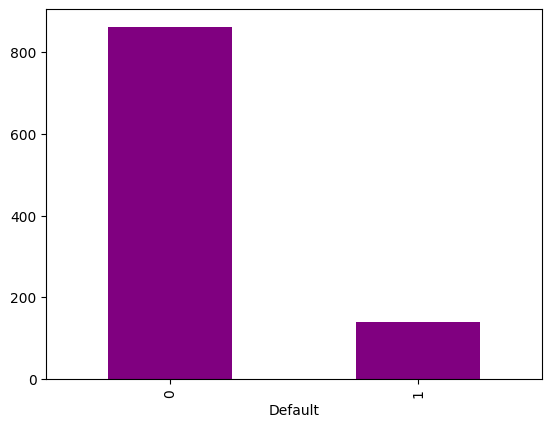

In [34]:
df['Default'].value_counts().plot(kind='bar',color='purple')

<Axes: >

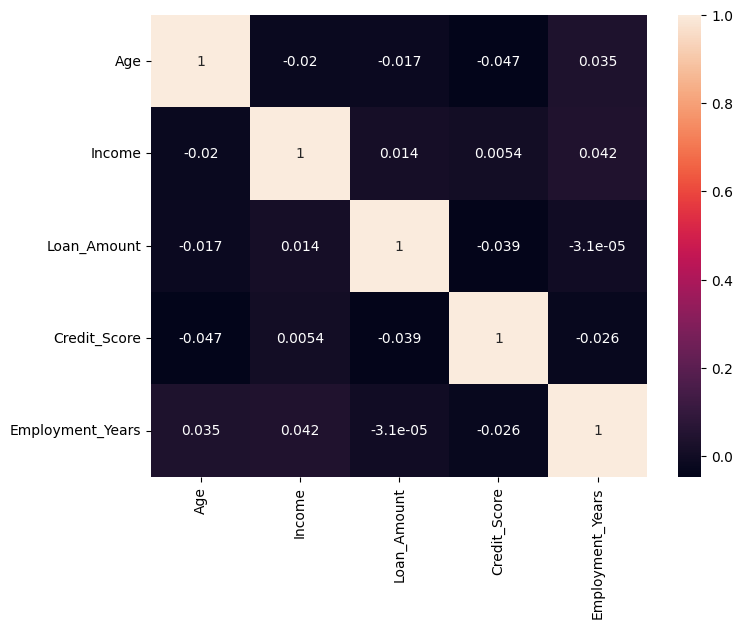

In [35]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True)

In [36]:
from sklearn.preprocessing import LabelEncoder

In [37]:
le = LabelEncoder()

In [38]:
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [39]:
df.head()

,Age,Income,Loan_Amount,Credit_Score,Employment_Years,Education_Level,Housing_Status,Default
0,59,52154.0,11276,823,15,0,1,0
1,49,116646.0,43663,315,5,3,1,0
2,35,61157.0,18994,428,8,2,1,1
3,63,52154.0,28499,408,26,0,2,0
4,28,148876.0,28040,832,3,2,1,1


In [40]:
X = df.drop('Default', axis=1)
y = df['Default']

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
from sklearn.preprocessing import StandardScaler

In [44]:
sc = StandardScaler()

In [46]:
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [47]:
from sklearn.linear_model import LogisticRegression

In [48]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [49]:
y_pred = model.predict(X_test)

In [52]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [51]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.86

In [53]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[172,   0],
       [ 28,   0]])

In [54]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92       172
           1       0.00      0.00      0.00        28

    accuracy                           0.86       200
   macro avg       0.43      0.50      0.46       200
weighted avg       0.74      0.86      0.80       200



c:\Users\Pawan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Pawan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Pawan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave